# Fuel Consumption Prediction of Vehicles

## Objective
The goal of this project is to predict the **fuel consumption (MPG)** of vehicles based on their attributes, including engine specifications, weight, and acceleration.

## Dataset Overview
The dataset contains records of vehicles with features relevant to fuel efficiency prediction.

## Instructions
1. **Data Exploration**: Load and examine the dataset.
2. **Data Preprocessing**: Handle missing values, encode categorical variables, and normalize numerical features.
3. **Feature Selection**: Identify important predictors for fuel efficiency.
4. **Model Training**: Train a regression model to predict fuel consumption (MPG).
5. **Evaluation**: Assess model performance using RMSE and R² score.

In [1]:

# Import necessary libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score


In [2]:

# Load the dataset (auto-mpg.data file)
column_names = ["mpg", "cylinders", "displacement", "horsepower", "weight", "acceleration", "model_year", "origin", "car_name"]
df = pd.read_csv('auto-mpg.data', sep=r'\s+', names=column_names, na_values='?')

# Display basic information about the dataset
print("--- Dataset Dimensions ---")

print(f"Data shape: {df.shape}\n")

print("--- Datatype Information ---")
print(df.info())

print("\n--- Summary Statistics ---")
print(df.describe())

--- Dataset Dimensions ---
Data shape: (398, 9)

--- Datatype Information ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           398 non-null    float64
 1   cylinders     398 non-null    int64  
 2   displacement  398 non-null    float64
 3   horsepower    392 non-null    float64
 4   weight        398 non-null    float64
 5   acceleration  398 non-null    float64
 6   model_year    398 non-null    int64  
 7   origin        398 non-null    int64  
 8   car_name      398 non-null    object 
dtypes: float64(5), int64(3), object(1)
memory usage: 28.1+ KB
None

--- Summary Statistics ---
              mpg   cylinders  displacement  horsepower       weight  \
count  398.000000  398.000000    398.000000  392.000000   398.000000   
mean    23.514573    5.454774    193.425879  104.469388  2970.424623   
std      7.815984    1.701004    

## Exploratory Data Analysis (EDA)
- Check for missing values
- Visualize key distributions
- Identify correlations between features

In [3]:
df.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,car_name
0,18.0,8,307.0,130.0,3504.0,12.0,70,1,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693.0,11.5,70,1,buick skylark 320
2,18.0,8,318.0,150.0,3436.0,11.0,70,1,plymouth satellite
3,16.0,8,304.0,150.0,3433.0,12.0,70,1,amc rebel sst
4,17.0,8,302.0,140.0,3449.0,10.5,70,1,ford torino


mpg             0
cylinders       0
displacement    0
horsepower      6
weight          0
acceleration    0
model_year      0
origin          0
car_name        0
dtype: int64


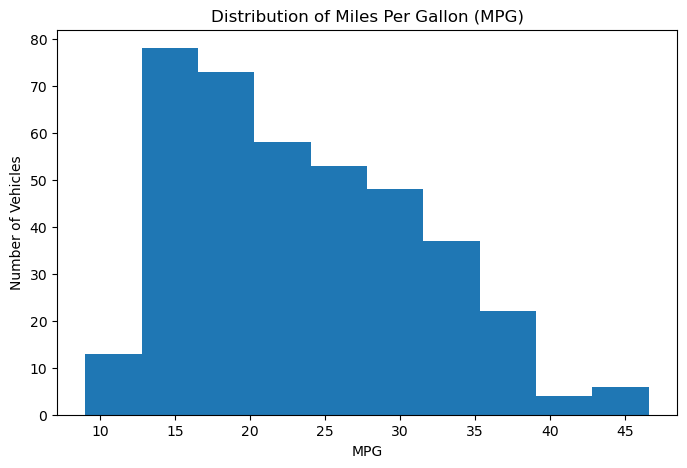


--- Heat map ---


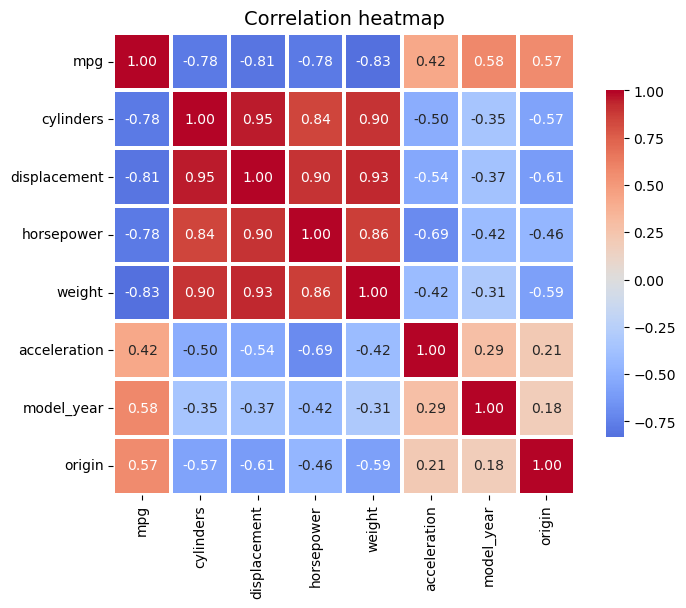

In [4]:
# Check for missing values
print(df.isnull().sum())

# Drop rows with missing values
df= df.dropna()

#df= df.drop(columns=['car_name'])


# Visualize MPG distribution

plt.figure(figsize=(8,5))
plt.hist(df['mpg'], bins=10)

plt.title('Distribution of Miles Per Gallon (MPG)')
plt.xlabel('MPG')
plt.ylabel('Number of Vehicles')

plt.show()

# Correlation heatmap (numerical features only)

print('\n--- Heat map ---')

corr = df.corr(numeric_only=True)

mask= np.triu(np.ones_like(corr, dtype=bool))
fig = plt.subplots(figsize=(8,6))

sns.heatmap(corr, annot=True, cmap= 'coolwarm', fmt='.2f', center=0, linecolor='white', linewidths=1.5,
            square=True, cbar_kws={"shrink" :0.75})
plt.title('Correlation heatmap', fontsize=14)

plt.show()

## EDA

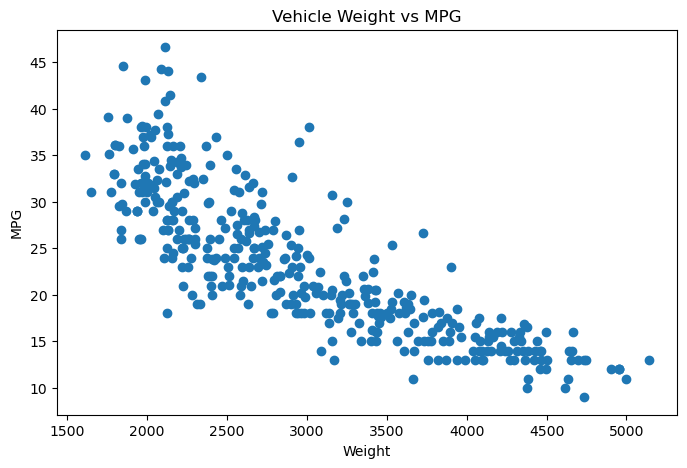

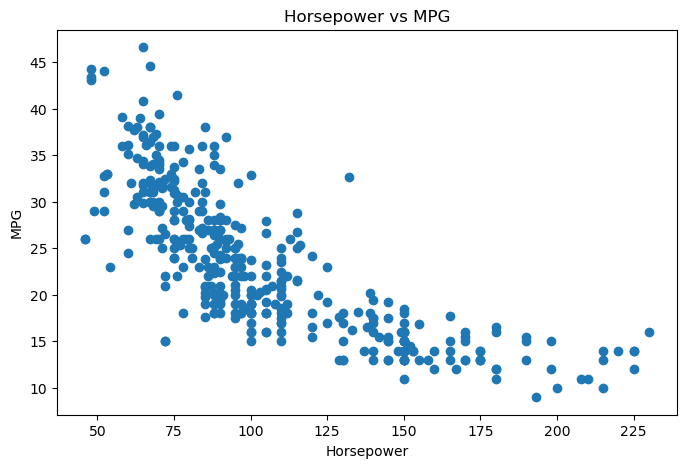

<Figure size 800x500 with 0 Axes>

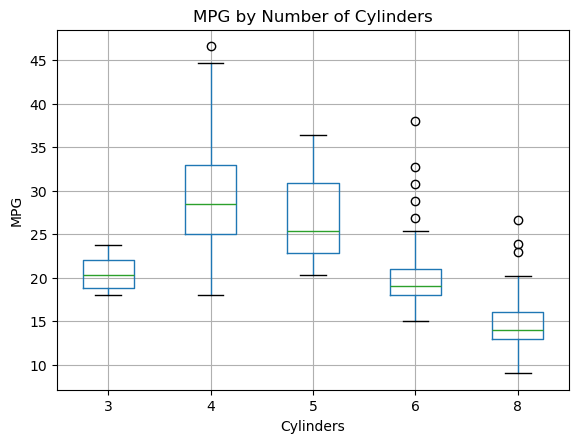

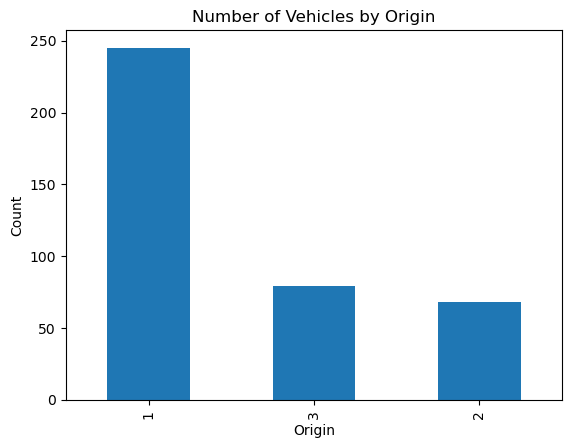

In [5]:
plt.figure(figsize=(8,5))
plt.scatter(df['weight'], df['mpg'])
plt.title('Vehicle Weight vs MPG')
plt.xlabel('Weight')
plt.ylabel('MPG')
plt.show()


plt.figure(figsize=(8,5))
plt.scatter(df['horsepower'], df['mpg'])
plt.title('Horsepower vs MPG')
plt.xlabel('Horsepower')
plt.ylabel('MPG')
plt.show()


plt.figure(figsize=(8,5))
df.boxplot(column='mpg', by='cylinders')
plt.title('MPG by Number of Cylinders')
plt.suptitle('')
plt.xlabel('Cylinders')
plt.ylabel('MPG')
plt.show()


df['origin'].value_counts().plot(kind='bar')
plt.title('Number of Vehicles by Origin')
plt.xlabel('Origin')
plt.ylabel('Count')
plt.show()

## Exploratory Data Analysis

### Key Findings

- *Vehicle weight has the strongest negative correlation with MPG (-0.83).*
- *Displacement and horsepower also show strong negative relationships with MPG.*
- *Model year has a positive correlation (0.58), indicating that newer vehicles tend to have better fuel efficiency.*
- *Vehicles with fewer cylinders generally achieve higher MPG.*

## Data Preprocessing
- Handle missing values
- Encode categorical variables
- Normalize numerical features

In [6]:
# Encode categorical variables (Origin as categorical feature)
# df = pd.get_dummies(df, columns=['origin'], drop_first=True)

# Define features and target variable

# Features (X) and Target (y)

X = df.drop(['mpg', 'car_name'], axis=1)
y = df['mpg']

# Split into train and test sets

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


from sklearn.preprocessing import StandardScaler

# Create the scaler
scaler = StandardScaler()

# Fit only on training data
X_train_scaled = scaler.fit_transform(X_train)

# Transform test data
X_test_scaled = scaler.transform(X_test)

scaled_df = pd.DataFrame(X_train_scaled,columns=X.columns)

scaled_df.head()

,cylinders,displacement,horsepower,weight,acceleration,model_year,origin
0,0.304862,0.284578,0.141429,0.754803,1.121759,0.494528,-0.689825
1,-0.873184,-0.535880,-0.329499,-0.493129,-0.228940,-0.057298,-0.689825
2,0.304862,-0.236655,-0.198685,-0.002530,-0.371118,-0.333211,-0.689825
3,1.482907,1.182255,1.187934,1.368052,-0.726565,-1.160950,-0.689825
4,-0.873184,-1.057113,-1.062052,-1.323099,0.304231,1.322266,-0.689825


### Obeservation

- *Missing values: Removed rows containing missing values using dropna().*
- *Categorical variables: No additional encoding was required because the dataset contained no text-based categorical features. The origin feature was already represented using numeric codes.*
- *Feature scaling: Numerical features were standardized using StandardScaler() to ensure all features were on a comparable scale before training the Linear Regression model.*

## Model Training
Train a **Linear Regression** model to predict fuel consumption.

Linear Regression Model Performance
----------------------------------------
R² Score:  0.7902
Mean Absolute Error (MAE): 2.4198
Mean Squared Error (MSE): 10.7109
Root Mean Squared Error (RMSE): 3.2727


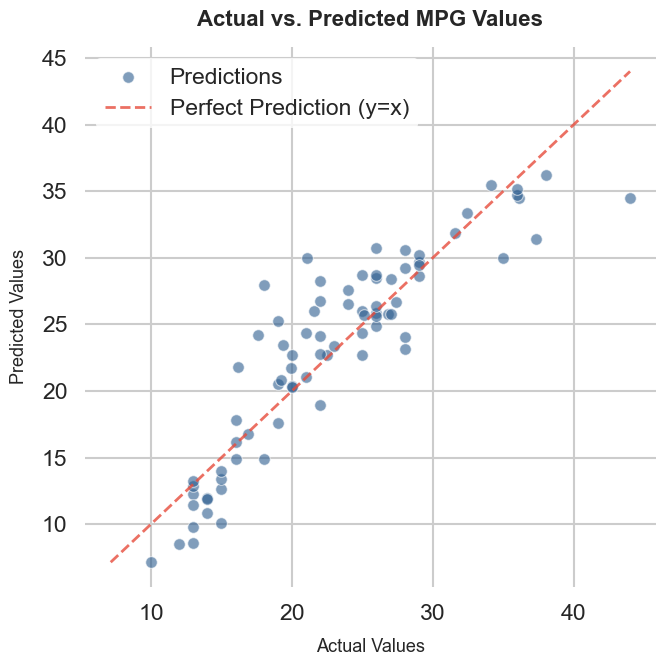

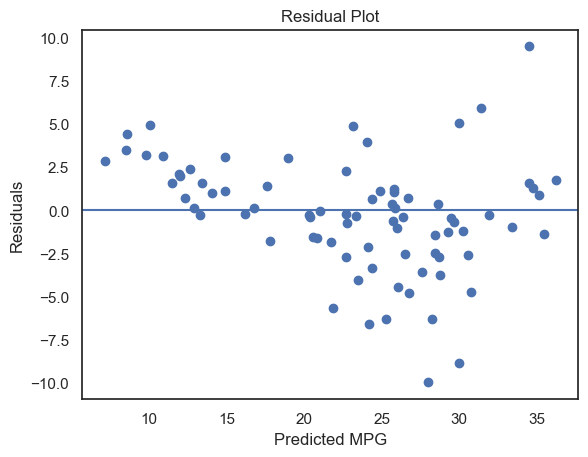

In [7]:
# Train a Linear Regression model
model = LinearRegression()


model.fit(X_train_scaled, y_train)

# Predictions
y_pred = model.predict(X_test_scaled)

# Model evaluation
print("Linear Regression Model Performance")
print("-" * 40)

print(f"R² Score: {r2_score(y_test, y_pred): .4f}")
print(f"Mean Absolute Error (MAE): {mean_absolute_error(y_test, y_pred):.4f}")
print(f"Mean Squared Error (MSE): {mean_squared_error(y_test, y_pred):.4f}")
print(f"Root Mean Squared Error (RMSE): {np.sqrt(mean_squared_error(y_test, y_pred)):.4f}")


##
comparison = pd.DataFrame({'Actual MPG': y_test,'Predicted MPG': y_pred})
comparison.head()

# Set a clean, professional theme
sns.set_theme(style="whitegrid", context="talk")

fig, ax = plt.subplots(figsize=(7, 7))

ax.scatter(
    y_test, y_pred,
    color="#2b5c8f", edgecolors="w",
    alpha=0.6,  # Transparency for overlapping points
    linewidth=0.8,
    s=70,  # Slightly larger marker size
    label="Predictions",
)

# Dynamically calculate matching limits for both axes
min_val = min(min(y_test), min(y_pred))
max_val = max(max(y_test), max(y_pred))
padding = (max_val - min_val) * 0.05

ax.set_xlim(min_val - padding, max_val + padding)
ax.set_ylim(min_val - padding, max_val + padding)

# Add the ideal 45-degree reference line
ax.plot(
    [min_val, max_val],
    [min_val, max_val],
    color="#e74c3c",  # Crimson red
    linestyle="--",
    linewidth=2,
    alpha=0.8,
    label="Perfect Prediction (y=x)",
)

# typography and spacing
ax.set_title("Actual vs. Predicted MPG Values", fontsize=16, fontweight="bold", pad=15)
ax.set_xlabel("Actual Values", fontsize=13, labelpad=10)
ax.set_ylabel("Predicted Values", fontsize=13, labelpad=10)

# Add a clean legend and remove distracting outer spines
ax.legend(loc="upper left", frameon=True, facecolor="white", edgecolor="none")
sns.despine(left=True, bottom=True)

plt.tight_layout()
plt.show()


residuals = y_test - y_pred

sns.set_theme(style="white")
plt.scatter(y_pred, residuals)
plt.axhline(y=0)
plt.xlabel("Predicted MPG")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()

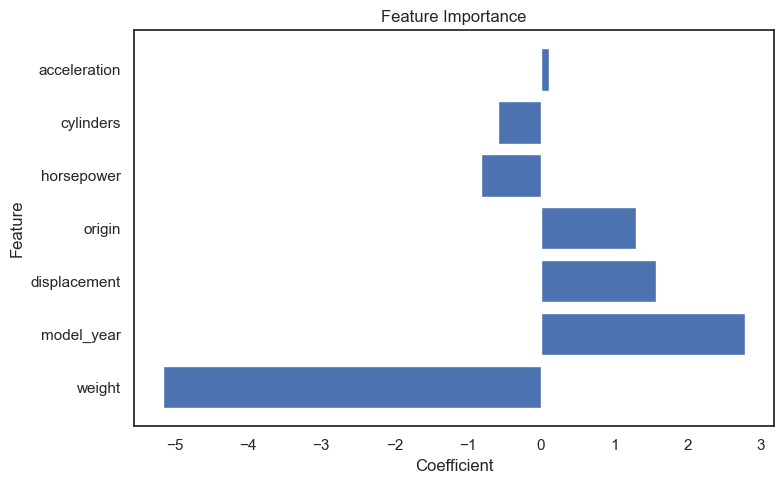

In [8]:
coef_df = pd.DataFrame({'Feature': X.columns, 'Coefficient': model.coef_})
sns.set_theme(style="white")
coef_df = coef_df.sort_values(by='Coefficient', key=abs, ascending= False)

plt.figure(figsize=(8,5))

plt.barh(coef_df['Feature'], coef_df['Coefficient'])
plt.xlabel("Coefficient")
plt.ylabel("Feature")
plt.title("Feature Importance")
plt.tight_layout()
plt.show()

## Feature Importance Analysis

- **Weight** was the most influential predictor of MPG, showing a strong negative relationship with fuel efficiency.
- **Model Year** had the strongest positive influence, indicating that newer vehicles generally achieve better fuel economy.
- **Horsepower** and **Cylinders** negatively affected MPG, suggesting that larger and more powerful engines consume more fuel.
- Although **Displacement** showed a positive coefficient in the regression model, it has a strong negative correlation with MPG. This difference is likely due to multicollinearity, as displacement is highly correlated with weight, horsepower, and cylinders.
- **Acceleration** had the smallest coefficient, indicating a relatively minor contribution to MPG prediction.